<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_Pass_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



## Problem Definition

- What is the Business Problem?  Often some variant of saving time, saving money, and/or making money.
*Which songs will be popular*
  - ***Ans: To predict which new songs will become popular on Spotify. By knowing this in advance, stakeholders (like music labels, artists, or streaming platforms) can save time, optimize marketing budgets, and maximize revenue by focusing resources on tracks with the highest potential.***
- What Data Science Problem is this? ( *Supervised* or Unsupervised )
  - ***Ans: This is a Supervised learning problem because the dataset includes a specific "target" or outcome variable (historical popularity data) that the model learns from to make future predictions.***
- If Supervised ...
  - How did you determine what is the target?
    - ***Ans: The target is the metric we want to predict. While there is a specific "popularity" column in the dataset, the instructions note that other columns might also serve as better or alternative indicators of a song's success.***
  - What is the Target?
    - ***Ans: Song Popularity***.
  - What statistical data type is the target: Numerical or Categorical?
    - ***Ans: The target is Numerical because popularity is typically measured as a continuous score or rank (a number), rather than a category (like "Good" or "Bad")***
  - Would this be a Classification or a *Regression* problem?
    - ***Ans: This is a Regression problem. Since the target is a continuous numerical value and the primary goal is to minimize the Root Mean Squared Error (RMSE), we are predicting an exact numerical value rather than sorting songs into discrete categories.***

##Data Collection

- Where is the data source located: local file, database, website, API, other?
  - ***Ans: The data is available on AWS S3 at***: https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv
- Where is the data dictionary?
  - ***Ans:The data dictionary and data information documentation can be accessed via the [RStudio Publications Spotify Dataset Documentation](https://rstudio-pubs-static.s3.amazonaws.com/905910_7f0cdad64be74075b0f0440c2fab6595.html?utm_source=chatgpt.com).***
- What tools did/would you use to get and read the data?

In [1]:
import numpy as np
import pandas as pd
import graphviz
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn import tree

In [56]:
# Storing the URL pointing to the Spotify CSV dataset hosted on AWS S3

url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

### Use Pandas to read and load dataset into Notebook!

In [3]:
# Using Pandas to read and load dataset

df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


In [59]:
# Checking the HTTP header of the S3 file to verify the file size (Content-Length), file type, and status

!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: eecV19zvVtTaqjBU9bUb70xIMdyUVmAUU1QJepjCgxsZOoNjCkRmOK9/qSGlPbKtwcle13ixaze4x6RlZP/1xRtbNoqoSwP4
x-amz-request-id: SRC4HRVKYXAE3432
Date: Wed, 15 Jul 2026 01:40:12 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [60]:
# Download and save the Spotify CSV dataset to the local Colab environment
!curl -s -O {url}

In [64]:
# Download the dataset again to ensure the local file is present and up to date
!curl -s -O {url}

In [63]:
# Inspect the first row (column headers) of the CSV file and print them as a numbered vertical list
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


In [4]:
# Replace empty spaces ' ' with NaN across the entire dataset
df = df.replace(r'^\s*$', np.nan, regex=True)

# Force known numerical columns to be numeric
numeric_cols = [
    'Popularity', 'Artist Followers', 'Streams', 'Highest Charting Position',
    'Number of Times Charted', 'Danceability', 'Energy', 'Loudness',
    'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaNs in numerical columns with their medians
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [5]:
# Getting general usefful information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Index                      1556 non-null   int64  
 1   Highest Charting Position  1556 non-null   int64  
 2   Number of Times Charted    1556 non-null   int64  
 3   Week of Highest Charting   1556 non-null   object 
 4   Song Name                  1556 non-null   object 
 5   Streams                    0 non-null      float64
 6   Artist                     1556 non-null   object 
 7   Artist Followers           1556 non-null   float64
 8   Song ID                    1545 non-null   object 
 9   Genre                      1545 non-null   object 
 10  Release Date               1545 non-null   object 
 11  Weeks Charted              1556 non-null   object 
 12  Popularity                 1556 non-null   float64
 13  Danceability               1556 non-null   float

In [6]:
# Getting a summary of the dataset

df.describe()

,Index,Highest Charting Position,Number of Times Charted,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
count,1556.000000,1556.000000,1556.000000,0.0,1.556000e+03,1556.000000,1556.000000,1556.000000,1556.00000,1556.000000,1556.000000,1556.000000,1556.000000,1556.000000,1556.000000
mean,778.500000,87.744216,10.668380,NaN,1.466131e+07,70.109897,0.690117,0.633555,-6.34594,0.123322,0.248075,0.180798,122.805375,197910.066195,0.514685
std,449.322824,58.147225,16.360546,NaN,1.662977e+07,15.769852,0.141946,0.161006,2.50057,0.110063,0.249547,0.143641,29.486315,46983.284093,0.226520
min,1.000000,1.000000,1.000000,NaN,4.883000e+03,0.000000,0.150000,0.054000,-25.16600,0.023200,0.000025,0.019700,46.718000,30133.000000,0.032000
25%,389.750000,37.000000,1.000000,NaN,2.142789e+06,65.000000,0.599750,0.533750,-7.48150,0.045700,0.049125,0.097050,97.971250,169354.750000,0.344000
50%,778.500000,80.000000,4.000000,NaN,6.852509e+06,73.000000,0.707000,0.642000,-5.99000,0.076500,0.161000,0.124000,122.012000,193591.000000,0.512000
75%,1167.250000,137.000000,12.000000,NaN,2.253630e+07,80.000000,0.795000,0.750000,-4.71850,0.164000,0.386000,0.215250,143.177750,218766.000000,0.690000
max,1556.000000,200.000000,142.000000,NaN,8.333778e+07,100.000000,0.980000,0.970000,1.50900,0.884000,0.994000,0.962000,205.272000,588139.000000,0.979000


In [7]:
# Generating descriptive statistics

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Index,1556.0,7.785000e+02,4.493228e+02,1.000000,3.897500e+02,7.785000e+02,1.167250e+03,1.556000e+03
Highest Charting Position,1556.0,8.774422e+01,5.814723e+01,1.000000,3.700000e+01,8.000000e+01,1.370000e+02,2.000000e+02
Number of Times Charted,1556.0,1.066838e+01,1.636055e+01,1.000000,1.000000e+00,4.000000e+00,1.200000e+01,1.420000e+02
Streams,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist Followers,1556.0,1.466131e+07,1.662977e+07,4883.000000,2.142789e+06,6.852509e+06,2.253630e+07,8.333778e+07
Popularity,1556.0,7.010990e+01,1.576985e+01,0.000000,6.500000e+01,7.300000e+01,8.000000e+01,1.000000e+02
Danceability,1556.0,6.901170e-01,1.419465e-01,0.150000,5.997500e-01,7.070000e-01,7.950000e-01,9.800000e-01
Energy,1556.0,6.335553e-01,1.610061e-01,0.054000,5.337500e-01,6.420000e-01,7.500000e-01,9.700000e-01
Loudness,1556.0,-6.345940e+00,2.500570e+00,-25.166000,-7.481500e+00,-5.990000e+00,-4.718500e+00,1.509000e+00
Speechiness,1556.0,1.233224e-01,1.100626e-01,0.023200,4.570000e-02,7.650000e-02,1.640000e-01,8.840000e-01


### Content length

  - How many bytes ( KB, MB, GB, TB ) is the data set?
    - ***738,124 bytes (which is approximately 738 KB or 0.74 MB)***

In [8]:
# Look at the headers
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: k9rEooFw1g+5Ex2ebEd0GZGDqA9GxJJmEYsBlvrxZXyiSdxZWfwnyMc0eyT2NtthQyWQ5GcjhKDsNfEVPX3Fnb0Hle1Wxha4
x-amz-request-id: HMTH6BJ8YHXQGWKY
Server: AmazonS3
Date: Wed, 15 Jul 2026 01:36:12 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Length: 738124
Content-Type: text/csv



##Data Cleaning

- How can/did you discover how many rows?
- How can/did you discover how many columns?

In [12]:
df.shape

(1556, 23)

In [22]:
# Checking for nulls and revealing columns that have fewer entries than the total 1,556 rows.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Index                      1556 non-null   int64  
 1   Highest Charting Position  1556 non-null   int64  
 2   Number of Times Charted    1556 non-null   int64  
 3   Week of Highest Charting   1556 non-null   object 
 4   Song Name                  1556 non-null   object 
 5   Streams                    0 non-null      float64
 6   Artist                     1556 non-null   object 
 7   Artist Followers           1556 non-null   float64
 8   Song ID                    1545 non-null   object 
 9   Genre                      1545 non-null   object 
 10  Release Date               1545 non-null   object 
 11  Weeks Charted              1556 non-null   object 
 12  Popularity                 1556 non-null   float64
 13  Danceability               1556 non-null   float

### Checking Uniqueness


- How can/did you discover if there are any unique identifiers and how would/did you handle them?

In [13]:
# inspecting the column names, 'Index' and 'Song ID' stand out as unique identifiers.
# 'Song ID' is a text-based code unique to each track on Spotify.

df['Song ID'].is_unique

False

In [14]:
unique_cols = [col for col in df.columns if df[col].is_unique]
display("Columns with completely unique values:", unique_cols)

'Columns with completely unique values:'

['Index', 'Song Name']

In [15]:
# DataFrame containing all column names

columns_list = [
    "Index", "Highest Charting Position", "Number of Times Charted",
    "Week of Highest Charting", "Song Name", "Streams", "Artist",
    "Artist Followers", "Song ID", "Genre", "Release Date",
    "Weeks Charted", "Popularity", "Danceability", "Energy",
    "Loudness", "Speechiness", "Acousticness", "Liveness",
    "Tempo", "Duration (ms)", "Valence", "Chord"
]

# Build a summary DataFrame
uniqueness_df = pd.DataFrame({"Column Name": columns_list})

# Check if each column in your actual dataset 'df' has entirely unique values
uniqueness_df["Unique"] = [df[col].is_unique for col in uniqueness_df["Column Name"]]

# Display the resulting table
uniqueness_df

,Column Name,Unique
0,Index,True
1,Highest Charting Position,False
2,Number of Times Charted,False
3,Week of Highest Charting,False
4,Song Name,True
5,Streams,False
6,Artist,False
7,Artist Followers,False
8,Song ID,False
9,Genre,False


- How can/did you discover if there are any nulls and how would/did you handle them?

In [16]:
# Checking for nulls. Output shows no nulls. So not dropping any for now.

df.isnull().sum()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,1556
Artist,0
Artist Followers,0
Song ID,11
Genre,11


- If Supervised, how can/did you discover if there are any nulls in your target and how would/did you handle them?

In [17]:
# Check specifically for missing values in the target

df['Popularity'].isnull().sum()

np.int64(0)

In [18]:
# Show only the rows where at least one value is missing (NaN)

df[df.isnull().any(axis=1)]
pd.DataFrame({"Column Name": columns_list})

,Column Name
0,Index
1,Highest Charting Position
2,Number of Times Charted
3,Week of Highest Charting
4,Song Name
5,Streams
6,Artist
7,Artist Followers
8,Song ID
9,Genre


In [19]:
# Count missing values in 'Popularity' and format as a DataFrame

missing_count = df['Popularity'].isnull().sum()

check_df = pd.DataFrame({
    "Target Column": ["Popularity"],
    "Missing Values Count": [missing_count]
})

check_df

,Target Column,Missing Values Count
0,Popularity,0


- How can/did you discover if there are any duplicates and how would/did you handle them?

In [20]:
# Checking for duplicate rows

df.duplicated().sum()

np.int64(0)

- How can/did you discover if there are any missing values and how would/did you handle them?



In [21]:
# checking for misssing value: identical to checking for nulls

df.isna().sum()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,1556
Artist,0
Artist Followers,0
Song ID,11
Genre,11



- How can/did you discover if there are any nested fields and how would/did you handle them?

In [23]:
# Visually inspecting the data preview, shows nested fields.

df['Genre'].head()

,Genre
0,"['indie rock italiano', 'italian pop']"
1,['australian hip hop']
2,['pop']
3,"['pop', 'uk pop']"
4,"['lgbtq+ hip hop', 'pop rap']"


In [24]:
# Creating a copy of the DataFrame to keep original data safe
df_clean_genre = df.copy()

# Using '.str.replace' with a regular expression to remove brackets and single quotes
# The pattern [\[\]'] matches '[', ']', and "'" and replaces them with an empty string ""
df_clean_genre['Genre'] = df_clean_genre['Genre'].str.replace(r"[\[\]']", "", regex=True)

# Preview the cleaned 'Genre' column alongside the Song Name
df_clean_genre[['Song Name', 'Genre']].head()

,Song Name,Genre
0,Beggin',"indie rock italiano, italian pop"
1,STAY (with Justin Bieber),australian hip hop
2,good 4 u,pop
3,Bad Habits,"pop, uk pop"
4,INDUSTRY BABY (feat. Jack Harlow),"lgbtq+ hip hop, pop rap"


## Exploratory Data Analysis

- If Supervised, what data type is your target?  What does that suggest for the type of ML process you will use?

### Target

In [25]:
# Defining our target

target = 'Highest Charting Position'
target

'Highest Charting Position'

In [26]:
# Dataframe showing target values

df[target]

,Highest Charting Position
0,1
1,2
2,1
3,3
4,5
...,...
1551,195
1552,196
1553,197
1554,198


In [27]:
# Are there nulls/NaNs in our target?

df[target].isnull().sum()

np.int64(0)

In [28]:
# What dtype is our target?
df[target].dtype

dtype('int64')

In [29]:
df[target].describe()

,Highest Charting Position
count,1556.000000
mean,87.744216
std,58.147225
min,1.000000
25%,37.000000
50%,80.000000
75%,137.000000
max,200.000000


### Categories

In [30]:
# Defining the features I can use BEFORE release

feature_cols = [
    'Song Name', 'Artist', 'Artist Followers', 'Genre', 'Release Date',
    'Duration (ms)', 'Chord', 'Danceability', 'Energy', 'Loudness',
    'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Valence'
]

# Defining our target column

target_col = ['Popularity']

# Define the post-release/leakage columns to exclude

exclude_cols = [
    'Index', 'Song ID', 'Highest Charting Position', 'Number of Times Charted',
    'Week of Highest Charting', 'Streams', 'Weeks Charted'
]

In [31]:
# Target Column(s)

display(target_col)

['Popularity']

In [32]:
# Create the target DataFrame/Series (y)

df_target = df[target_col]
df_target

,Popularity
0,100.0
1,99.0
2,99.0
3,98.0
4,96.0
...,...
1551,79.0
1552,66.0
1553,81.0
1554,60.0


In [33]:
# Feature Columns

display(feature_cols)

['Song Name',
 'Artist',
 'Artist Followers',
 'Genre',
 'Release Date',
 'Duration (ms)',
 'Chord',
 'Danceability',
 'Energy',
 'Loudness',
 'Speechiness',
 'Acousticness',
 'Liveness',
 'Tempo',
 'Valence']

In [34]:
# Creating the features DataFrame (X)

df_features = df[feature_cols]
df_features

,Song Name,Artist,Artist Followers,Genre,Release Date,Duration (ms),Chord,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Valence
0,Beggin',Måneskin,3377762.0,"['indie rock italiano', 'italian pop']",2017-12-08,211560.0,B,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,0.589
1,STAY (with Justin Bieber),The Kid LAROI,2230022.0,['australian hip hop'],2021-07-09,141806.0,C#/Db,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,0.478
2,good 4 u,Olivia Rodrigo,6266514.0,['pop'],2021-05-21,178147.0,A,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,0.688
3,Bad Habits,Ed Sheeran,83293380.0,"['pop', 'uk pop']",2021-06-25,231041.0,B,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,0.591
4,INDUSTRY BABY (feat. Jack Harlow),Lil Nas X,5473565.0,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,212000.0,D#/Eb,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,0.894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,New Rules,Dua Lipa,27167675.0,"['dance pop', 'pop', 'uk pop']",2017-06-02,209320.0,A,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,0.608
1552,Cheirosa - Ao Vivo,Jorge & Mateus,15019109.0,"['sertanejo', 'sertanejo universitario']",2019-10-11,181930.0,B,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,0.714
1553,Havana (feat. Young Thug),Camila Cabello,22698747.0,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,217307.0,D,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,0.394
1554,Surtada - Remix Brega Funk,"Dadá Boladão, Tati Zaqui, OIK",208630.0,"['brega funk', 'funk carioca']",2019-09-25,152784.0,F,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,0.881


In [35]:
# Excluded Column(s) for now

display(exclude_cols)

['Index',
 'Song ID',
 'Highest Charting Position',
 'Number of Times Charted',
 'Week of Highest Charting',
 'Streams',
 'Weeks Charted']

In [36]:
# Create the excluded columns DataFrame (in case I need to reference them later)

df_excluded = df[exclude_cols]
df_excluded

,Index,Song ID,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Streams,Weeks Charted
0,1,3Wrjm47oTz2sjIgck11l5e,1,8,2021-07-23--2021-07-30,NaN,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
1,2,5HCyWlXZPP0y6Gqq8TgA20,2,3,2021-07-23--2021-07-30,NaN,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
2,3,4ZtFanR9U6ndgddUvNcjcG,1,11,2021-06-25--2021-07-02,NaN,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
3,4,6PQ88X9TkUIAUIZJHW2upE,3,5,2021-07-02--2021-07-09,NaN,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...
4,5,27NovPIUIRrOZoCHxABJwK,5,1,2021-07-23--2021-07-30,NaN,2021-07-23--2021-07-30
...,...,...,...,...,...,...,...
1551,1552,2ekn2ttSfGqwhhate0LSR0,195,1,2019-12-27--2020-01-03,NaN,2019-12-27--2020-01-03
1552,1553,2PWjKmjyTZeDpmOUa3a5da,196,1,2019-12-27--2020-01-03,NaN,2019-12-27--2020-01-03
1553,1554,1rfofaqEpACxVEHIZBJe6W,197,1,2019-12-27--2020-01-03,NaN,2019-12-27--2020-01-03
1554,1555,5F8ffc8KWKNawllr5WsW0r,198,1,2019-12-27--2020-01-03,NaN,2019-12-27--2020-01-03


### Verifying Dataframe Splits

In [37]:
# Define your target
df_target = df[['Popularity']]

# Select ONLY numeric columns for features, completely ignoring all text/dates
numeric_cols_df = df.select_dtypes(include=[np.number])

# Drop 'Popularity' (and 'Index' if it exists) so they aren't used as predictors
cols_to_drop = ['Popularity', 'Index', 'Unnamed: 0']
df_features = numeric_cols_df.drop(columns=[col for col in cols_to_drop if col in numeric_cols_df.columns])

# Verify the split
print("Main DataFrame shape:      ", df.shape)
print("Features DataFrame shape:  ", df_features.shape)
print("Target DataFrame shape:    ", df_target.shape)

Main DataFrame shape:       (1556, 23)
Features DataFrame shape:   (1556, 13)
Target DataFrame shape:     (1556, 1)


- What is the distribution of values for your target?

In [38]:
feature = 'Artist Followers'
feature

'Artist Followers'

In [39]:
# SQRT of the number of rows to get bin size

n = int(1556**(1/2))
n

39

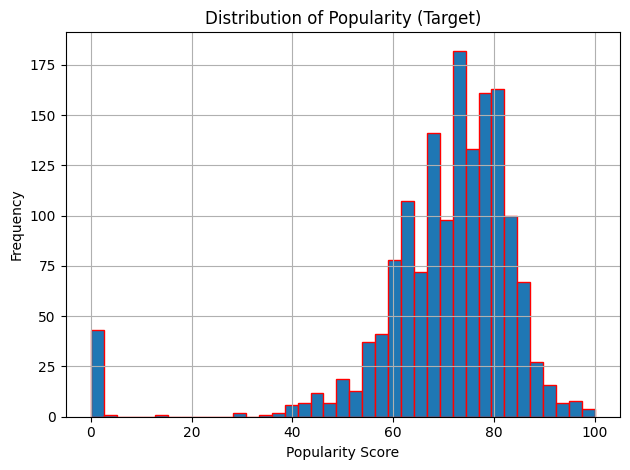

In [40]:
# Set bin size
n = 39

# Force the actual data inside the column to be numeric
# Making sure to pass df_target['Popularity'], NOT just the string 'Popularity')

target_numeric = pd.to_numeric(df_target['Popularity'], errors='coerce')

# Drop any resulting NaN values so matplotlib can plot cleanly
target_numeric = target_numeric.dropna()

# Plot your target distribution histogram
target_numeric.hist(bins=n, edgecolor='red')
plt.title('Distribution of Popularity (Target)')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Boxplot

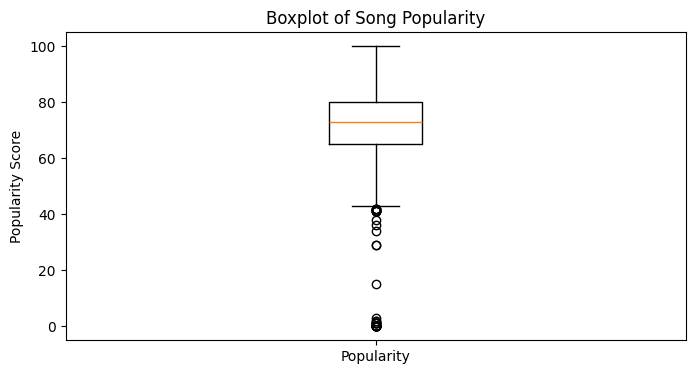

In [41]:
plt.figure(figsize=(8, 4))

# 1. Force the 'Popularity' column in df_target to be numeric and drop any NaNs
clean_popularity = pd.to_numeric(df_target['Popularity'], errors='coerce').dropna()

# 2. Create the boxplot using 'tick_labels' instead of 'labels'
_ = plt.boxplot(clean_popularity, tick_labels=['Popularity'])

plt.title('Boxplot of Song Popularity')
plt.ylabel('Popularity Score')
plt.show()

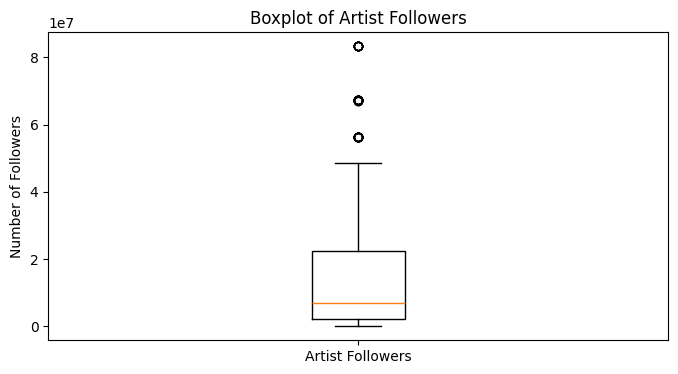

In [42]:


plt.figure(figsize=(8, 4))

# 1. Force 'Artist Followers' to be numeric and clean missing values
clean_followers = pd.to_numeric(df_features['Artist Followers'], errors='coerce').dropna()

# 2. Create the boxplot using the modern 'tick_labels' parameter to prevent warnings
_ = plt.boxplot(clean_followers, tick_labels=['Artist Followers'])

plt.title('Boxplot of Artist Followers')
plt.ylabel('Number of Followers')
plt.show()

- How can/did you discover which fields are Categorical?

In [43]:
# Shows the data type of every column in the features DataFrame
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Highest Charting Position  1556 non-null   int64  
 1   Number of Times Charted    1556 non-null   int64  
 2   Streams                    0 non-null      float64
 3   Artist Followers           1556 non-null   float64
 4   Danceability               1556 non-null   float64
 5   Energy                     1556 non-null   float64
 6   Loudness                   1556 non-null   float64
 7   Speechiness                1556 non-null   float64
 8   Acousticness               1556 non-null   float64
 9   Liveness                   1556 non-null   float64
 10  Tempo                      1556 non-null   float64
 11  Duration (ms)              1556 non-null   float64
 12  Valence                    1556 non-null   float64
dtypes: float64(11), int64(2)
memory usage: 158.2 KB


In [44]:
# Select columns with text/object data types
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()

print("Categorical Columns:")
display(categorical_cols)

Categorical Columns:


[]

In [45]:
# Show how many distinct categories/labels exist in your text columns
df_features.select_dtypes(include=['object']).nunique()

,0


- How can/did you discover which fields are Numerical?

- For each field, what is the distribution?

- How can/did you discover the relationship between any two variables?




##Processing
Use modeling techniques to gain useful insights into data and meet objectives of the project.

- What questions did you ask to determine which ML process to use?
- How did/can you determine what performance metric to use?  What others could you have used?  Which metrics might not be appropriate?
- How did/can you account for the variance/bias trade-off?

In [46]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

## Decision Trees

In [47]:
y = df[target]
X = df[[feature]]

In [48]:
# Explicitly set clean features and target variable
X = df_features
y = df_target['Popularity']

numLoops = 100
rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = DecisionTreeRegressor(max_depth=3)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 10890.0


In [49]:
# Force all columns in df_features to be numeric, turning empty strings/spaces into NaN

X_clean = df_features.apply(pd.to_numeric, errors='coerce')
X = X_clean.fillna(X_clean.median())

# Parse the target column first, then safely use its median to fill blanks
y_clean = pd.to_numeric(df_target['Popularity'], errors='coerce')
y = y_clean.fillna(y_clean.median())

# Run your loop
numLoops = 100
rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 10400.0


## Choosing Depth of Tree



In [50]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 100

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [51]:
pd.DataFrame(zip(max_depths, rms_depth, std_depth))

,0,1,2
0,1,15.341371,1.124346
1,2,13.774894,2.490972
2,3,10.734791,1.575163
3,4,10.100449,1.428207
4,5,9.999321,1.239310
5,6,10.284624,1.210493
6,7,10.279602,1.083914
7,8,10.635492,0.970273
8,9,10.999861,1.003183
9,10,11.259533,1.188650


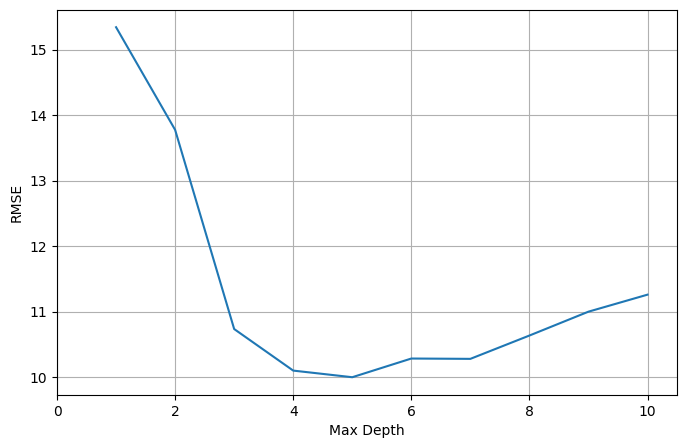

In [52]:
 #Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [53]:
#Re run with max depth = 4
numLoops = 100

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 10100.0


###Visualize the Decision Tree

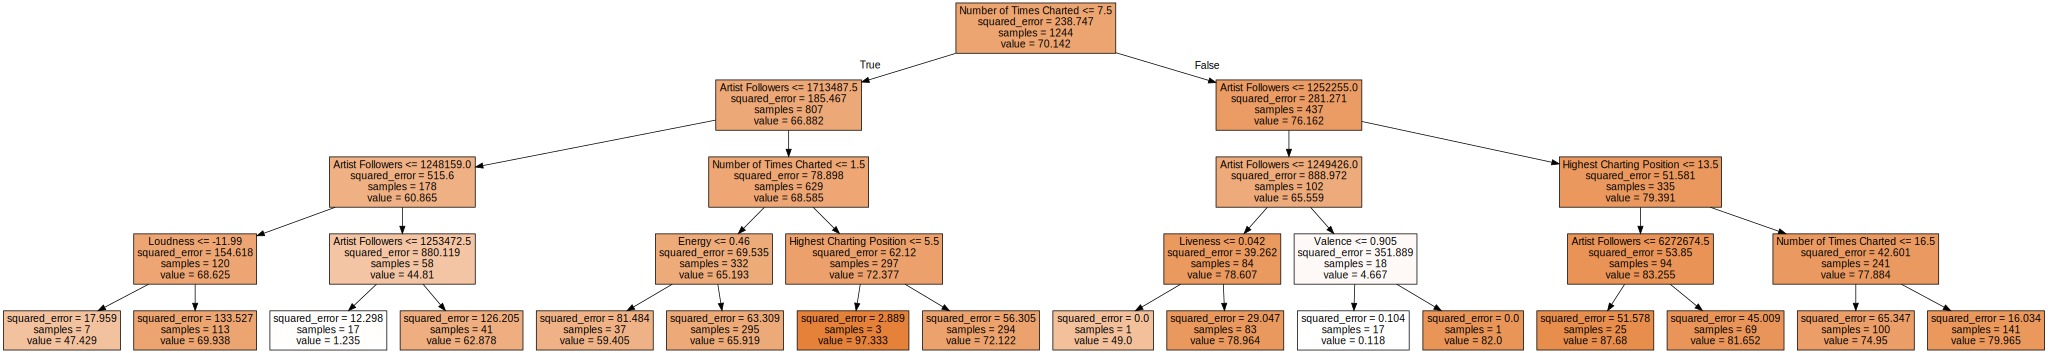

In [54]:
#Readable view
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

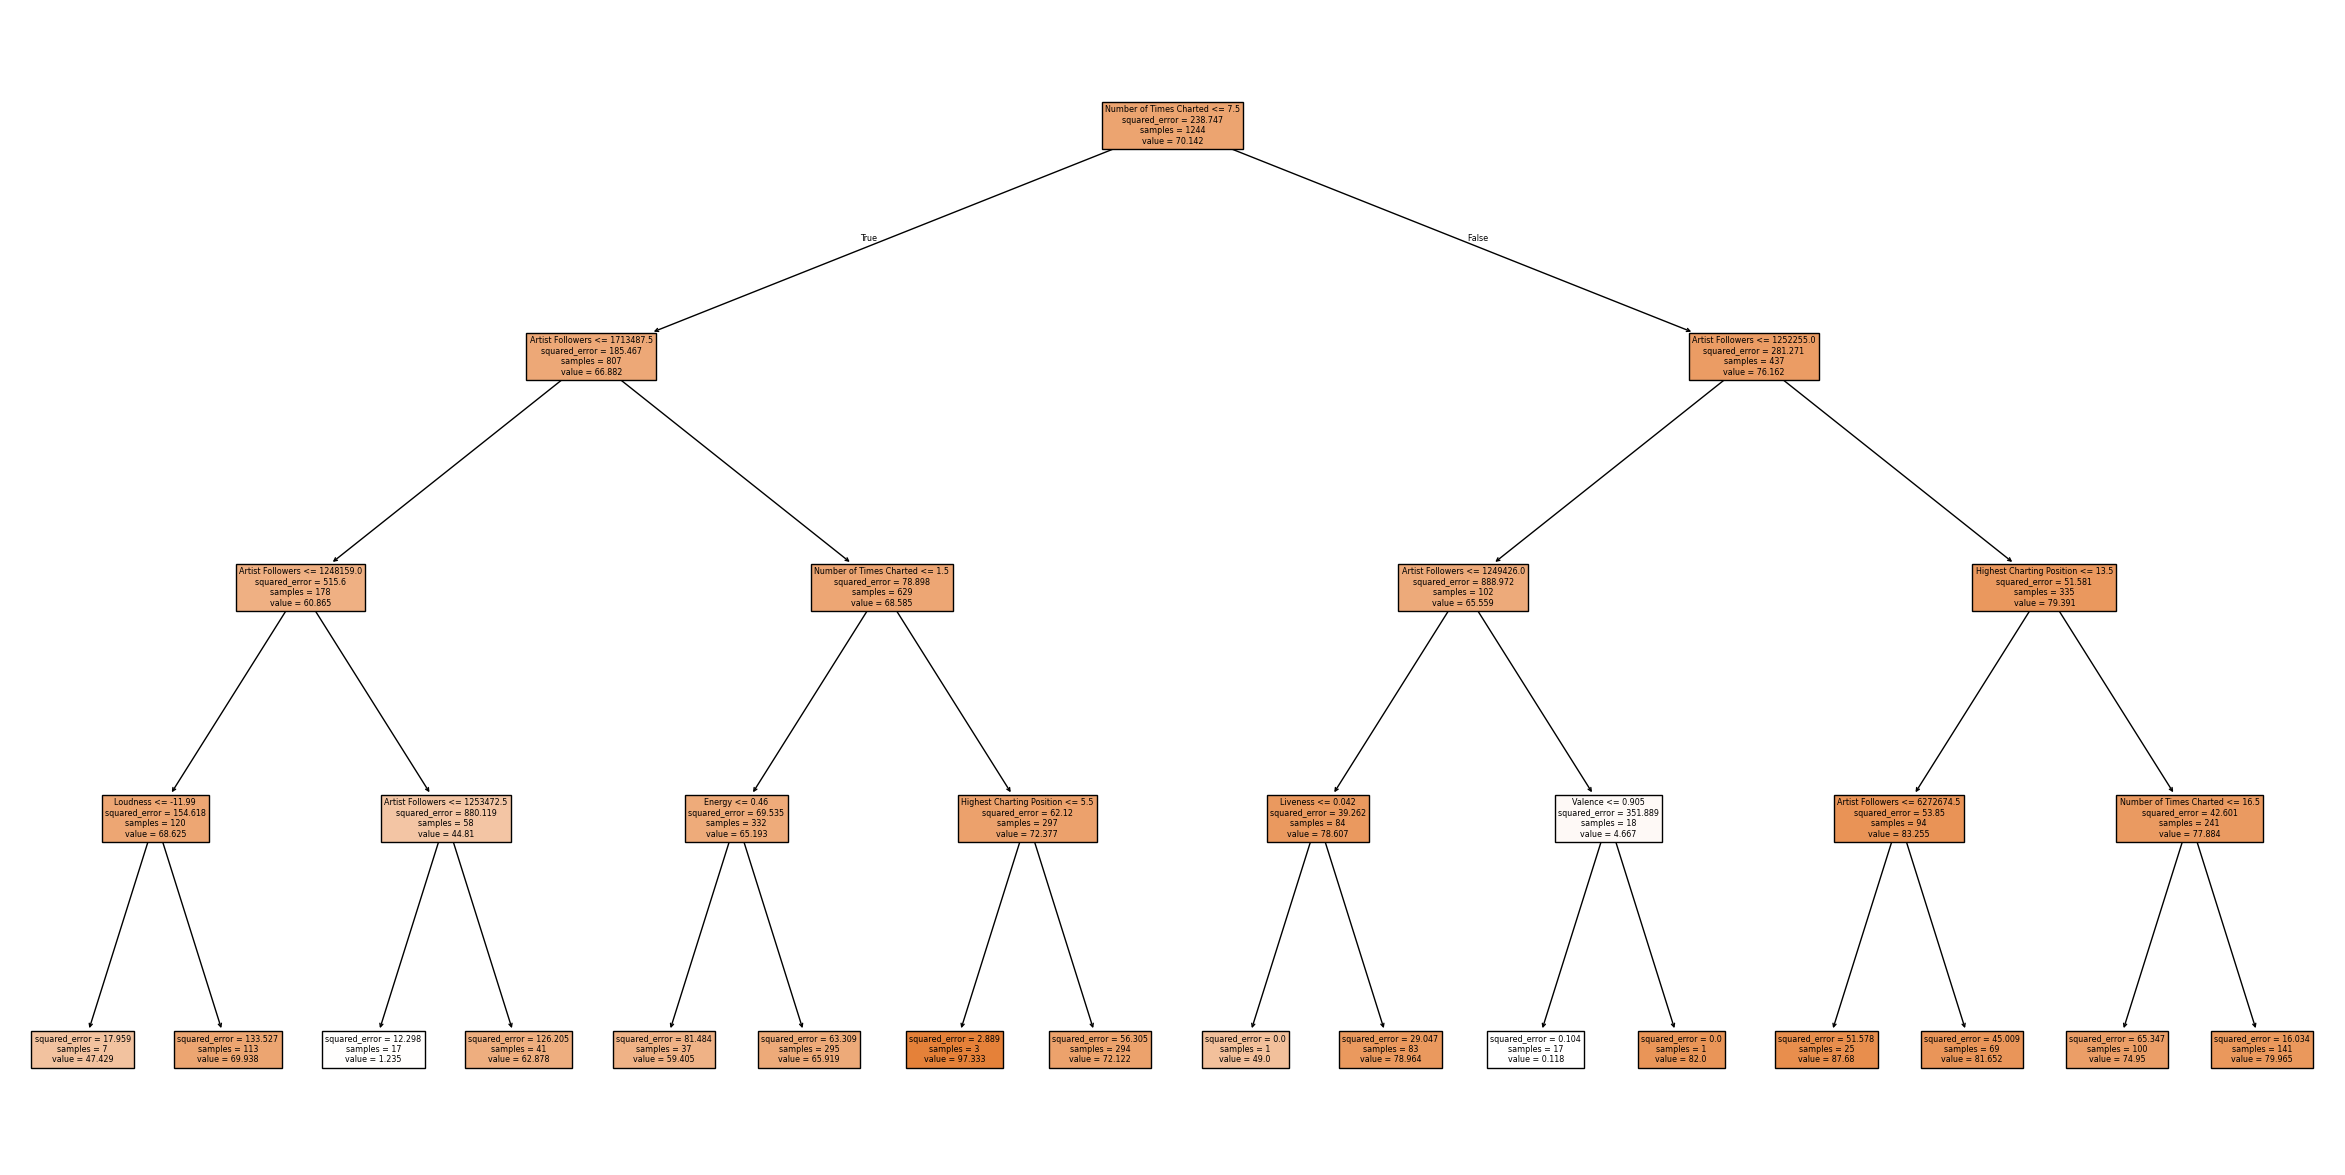

In [55]:
#Full view
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

## Conclusion

## Future Work

  - Choose a different target
  - test other models RF and XGB
  - Use One-Hot Encodeing for objects